In [1]:
import os, sys
sys.path.append('../')

import pandas as pd
import numpy as np

from tqdm.notebook import tqdm

from pathlib import Path
import importlib

import FOM_functions      as FOM
import cutting_functions  as cutf
import fitting_functions  as fitf
import plotting_functions as plotf

importlib.reload(FOM)
importlib.reload(fitf)



/home/e78368jw/anaconda3/envs/IC-3.13-2026-03-09/lib/python3.13/site-packages/zfit/__init__.py:93: UserWarning: TensorFlow warnings are by default suppressed by zfit. In order to show them, set the environment variable ZFIT_DISABLE_TF_WARNINGS=0. In order to suppress the TensorFlow warnings AND this warning, set ZFIT_DISABLE_TF_WARNINGS=1.
  warnings.warn(


<module 'fitting_functions' from '/home/e78368jw/Documents/NEXT_CODE/next_misc/new_FOM_method/testing/../fitting_functions.py'>

In [57]:
# load in data
timestamp = '658015'
data = pd.read_hdf(f'/home/e78368jw/Documents/topology_data/p_scan_110526/{timestamp}/full_dataset_15589_15590_15591_15592_{timestamp}.h5', 'Tracking/Tracks') 
display(data)

,event,trackID,energy,length,numb_of_voxels,numb_of_hits,numb_of_tracks,x_min,y_min,z_min,...,blob1_z,blob2_x,blob2_y,blob2_z,eblob1,eblob2,ovlp_blob_energy,vox_size_x,vox_size_y,vox_size_z
1,94718,0,1.527448,490.620388,434,1040,1,73.175,-124.275,565.150000,...,588.243094,165.475,-63.075,852.613875,0.770077,0.260604,0.0,14.296429,13.845000,14.507443
2,3728425,0,1.677750,304.468316,402,1032,1,-65.775,91.425,715.262000,...,779.443219,42.075,137.075,939.331625,0.706760,0.652495,0.0,14.170833,14.200000,14.764600
18,3033479,0,1.759690,295.246893,402,1014,1,42.075,-233.125,713.303125,...,804.317911,104.275,-31.975,748.349280,1.033580,0.275615,0.0,14.170833,14.714286,13.919422
0,2323364,0,1.720281,392.195675,443,1099,1,-65.775,60.325,467.615750,...,653.124625,-19.125,183.725,486.754915,0.748849,0.318248,0.0,14.453125,14.276923,14.792563
0,2203699,0,1.568839,414.399924,438,1024,1,26.525,-202.025,662.287250,...,918.625989,212.125,-78.625,717.980000,0.966412,0.268119,0.0,14.515625,14.170833,14.638054
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,2142553,0,1.623346,266.437520,322,779,1,-250.375,-0.875,153.392125,...,276.300781,-65.775,75.875,246.404641,0.640707,0.386620,0.0,14.517647,14.453125,14.223042
12,380219,0,1.543147,301.943863,421,973,1,-81.325,-16.425,816.543250,...,943.774247,104.275,60.325,870.905419,0.833633,0.195588,0.0,14.626316,14.200000,14.793103
4,730695,0,1.609662,316.434576,433,1046,1,-173.625,-139.825,756.441125,...,777.474823,10.975,29.225,808.105750,0.818098,0.405221,0.0,14.714286,14.517647,13.881146
7,1066681,0,1.711557,270.959432,457,1197,1,-96.875,44.775,983.294125,...,1079.349850,-19.125,91.425,1021.710315,1.055420,0.400692,0.0,14.170833,14.672500,14.756900


Initial gaussian and sigma: 1.5916200549498098, 0.009079257405323756


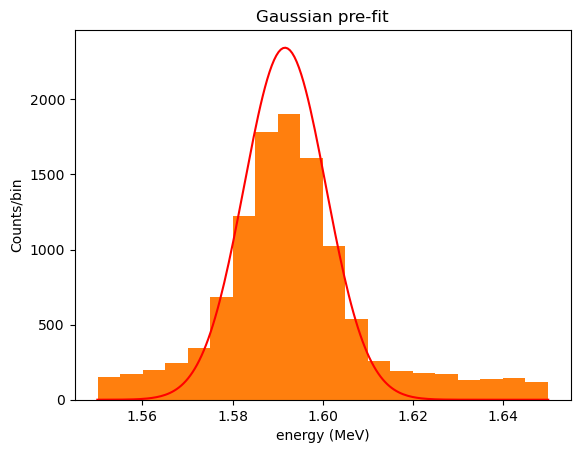

Blob cut: 0.0 MeV
Printing over integral range (np.float64(1.5643822827338385), np.float64(1.6188578271657812))
Signal events: [8143.98048167]
Background events: [1630.98994827]
Total events by addition: 20145.0510854697
Total events by row counting: 20118
Total events by addition in ROI: [9774.97042994]
Total events by row counting in ROI: 9771
FOM: [1.] +/- [0.02349771]


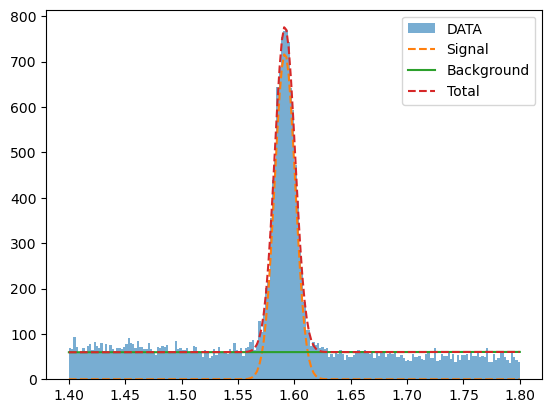

Blob cut: 0.016666666666666666 MeV
Printing over integral range (np.float64(1.5643822827338385), np.float64(1.6188578271657812))
Signal events: [8141.16326178]
Background events: [1630.55759565]
Total events by addition: 20139.050767402885
Total events by row counting: 20112
Total events by addition in ROI: [9771.72085743]
Total events by row counting in ROI: 9768
FOM: [0.9997866] +/- [0.02349447]


KeyboardInterrupt: 

In [78]:
cut_list = np.linspace(0, 0.8, 31)
fit_info = dict(bins = 80, fit_range = (1.4, 1.8))

mu_config    = dict(
                value    = 1.59,
                floating = False,
                lower    = 1.4,
                upper    = 1.8)

sigma_config = dict(
                value    = 0.1,
                floating = False,
                lower    = 0)

tau_config   = dict(
                value    = 0.03,
                floating = False,
                lower    = 0,
                upper    = 1)


seeds = dict(
            ns = data.event.nunique()/2,
            nb = data.event.nunique()/2,
            signal = {'mu_config': mu_config,
                      'sigma_config': sigma_config},
            background = {'lambda_config': tau_config})


# mkdir
output_path = Path(f'./output/{timestamp}').mkdir(parents = True, exist_ok=True)

x = FOM.FOM(data, fitf.gaussian_no_N, fitf.exp_no_N, seeds = seeds, fitting_info = fit_info, plot = True, output_path = f'./output/{timestamp}/')



In [2]:
# load in the csv and visualise
import csv
import matplotlib.pyplot as plt

def read_FOM_csv(path):
    data = np.genfromtxt(path, delimiter=',')
    n    = len(data) // 5

    return dict(
        cut_list = data[0*n : 1*n, 0],
        fom      = data[0*n : 1*n, 1],
        fom_err  = data[1*n : 2*n, 1],
        ns_l     = data[2*n : 3*n, 0],
        nb_l     = data[2*n : 3*n, 1],
        e        = data[3*n : 4*n, 0],
        e_err    = data[3*n : 4*n, 1],
        b        = data[4*n : 5*n, 0],
        b_err    = data[4*n : 5*n, 1],
    )

FOM_info = read_FOM_csv(f'output/{timestamp}/FOM.csv')


FOM_clean = FOM_info['fom']
FOM_clean[(FOM_clean > 5) | (FOM_clean < 0)] = 0

print('='*20)
print(f'{timestamp}')
print('='*20)
plt.errorbar(FOM_info['cut_list'], FOM_clean, yerr = FOM_info['fom_err'])
plt.xlabel('blob energy (MeV)')
plt.title(f'{timestamp}')
plt.ylabel('FOM')
plt.grid()
plt.show()
max_fom_index = np.argmax(FOM_clean)
max_fom       = FOM_clean[max_fom_index]
cut_pos       = FOM_info['cut_list'][max_fom_index]
print(f"Max FOM as {max_fom:.2f} at {cut_pos:.2f} MeV")
print(f"Signal events at peak: {FOM_info['ns_l'][max_fom_index]:.2f}")
print(f"Background events at peak: {FOM_info['nb_l'][max_fom_index]:.2f}")
print(f"Initial signal events: {FOM_info['ns_l'][0]:.2f}")
print(f"Initial background events: {FOM_info['nb_l'][0]:.2f}")

NameError: name 'timestamp' is not defined

  0%|          | 0/5 [00:00<?, ?it/s]

557024
'yerr' (shape: (36, 1)) must be a scalar or a 1D or (2, n) array-like whose shape matches 'y' (shape: (36, 1))
557024






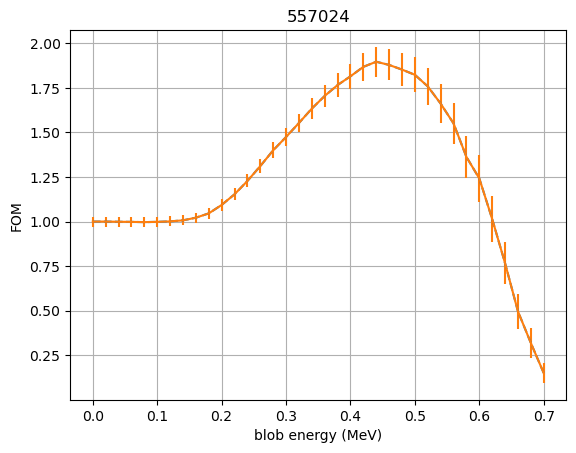

Max FOM as 1.90 at 0.44 MeV
Signal events at peak: 3568.90
Background events at peak: 199.38
Initial signal events: 4933.62
Initial background events: 1370.12
658015
'yerr' (shape: (41, 1)) must be a scalar or a 1D or (2, n) array-like whose shape matches 'y' (shape: (41, 1))
658015






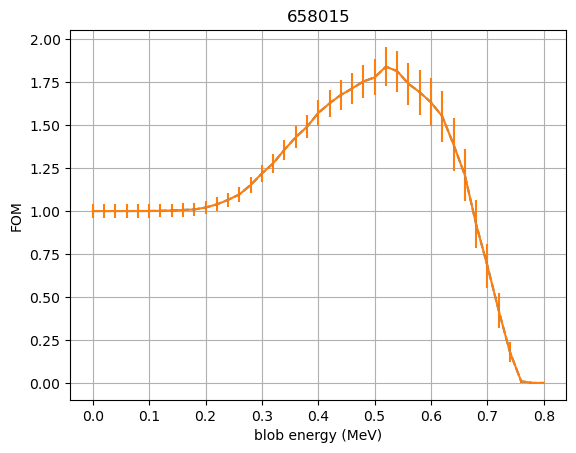

Max FOM as 1.84 at 0.52 MeV
Signal events at peak: 1380.29
Background events at peak: 103.71
Initial signal events: 2161.45
Initial background events: 861.13
658018
'yerr' (shape: (41, 1)) must be a scalar or a 1D or (2, n) array-like whose shape matches 'y' (shape: (41, 1))
658018






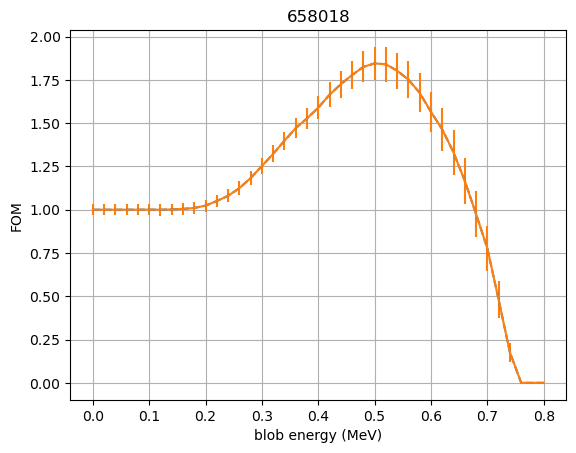

Max FOM as 1.85 at 0.50 MeV
Signal events at peak: 2127.70
Background events at peak: 153.55
Initial signal events: 3066.24
Initial background events: 1085.72
658021
'yerr' (shape: (41, 1)) must be a scalar or a 1D or (2, n) array-like whose shape matches 'y' (shape: (41, 1))
658021






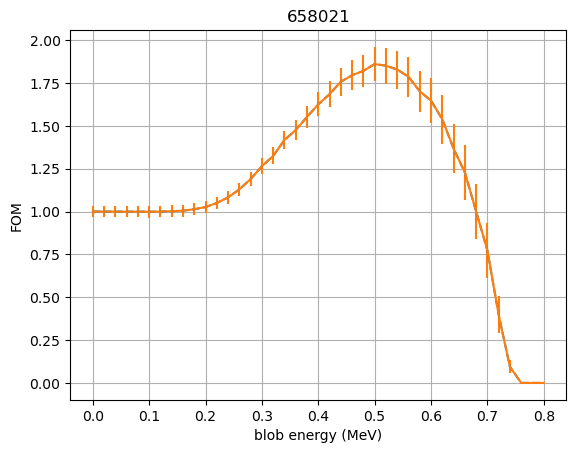

Max FOM as 1.86 at 0.50 MeV
Signal events at peak: 1930.06
Background events at peak: 138.58
Initial signal events: 2883.48
Initial background events: 1070.68
658024
'yerr' (shape: (41, 1)) must be a scalar or a 1D or (2, n) array-like whose shape matches 'y' (shape: (41, 1))
658024






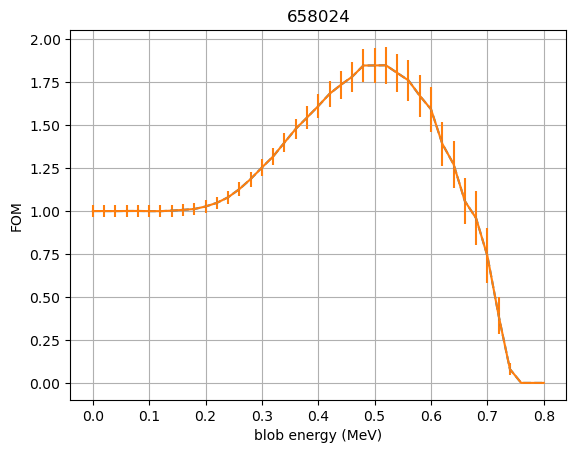

Max FOM as 1.85 at 0.52 MeV
Signal events at peak: 1687.81
Background events at peak: 116.98
Initial signal events: 2717.98
Initial background events: 1036.21


In [3]:
# massive iterator
#ts_list = [355015, 355018, 355021, 355024, 456015, 456018, 456021, 456024, 557015, 557018, 557021, 557024, 658015, 658018, 658021, 658024]
#ts_list = [456015, 456018, 456021, 456024, 557015, 557018, 557021, 557024, 658015, 658018, 658021, 658024]
ts_list = [557024, 658015, 658018, 658021, 658024]
ts_list = [str(x) for x in ts_list]

for timestamp in tqdm(ts_list):
    data = pd.read_hdf(f'/home/e78368jw/Documents/topology_data/p_scan_110526/{timestamp}/full_dataset_15589_15590_15591_15592_{timestamp}.h5', 'Tracking/Tracks') 

    print('='*20)
    print(f'{timestamp}')
    print('='*20)

    if '6580' in timestamp:
        cut_list = np.linspace(0, 0.8, 41)
    elif '5570' in timestamp:
        cut_list = np.linspace(0, 0.7, 36)
    else:
        cut_list = np.linspace(0, 0.6, 31)
    
    fit_info = dict(bins = 80, fit_range = (1.4, 1.8))

    mu_config    = dict(
                    value    = 1.59,
                    floating = False,
                    lower    = 1.4,
                    upper    = 1.8)

    sigma_config = dict(
                    value    = 0.1,
                    floating = False,
                    lower    = 0)

    tau_config   = dict(
                    value    = 0.03,
                    floating = False,
                    lower    = 0,
                    upper    = 1)


    seeds = dict(
                ns = data.event.nunique()/2,
                nb = data.event.nunique()/2,
                signal = {'mu_config': mu_config,
                          'sigma_config': sigma_config},
                background = {'lambda_config': tau_config})


    # mkdir
    output_path = Path(f'./output/{timestamp}').mkdir(parents = True, exist_ok=True)

    x = FOM.FOM(data, fitf.gaussian_no_N, fitf.exp_no_N, seeds = seeds, fitting_info = fit_info, plot = False, output_path = f'./output/{timestamp}/', cut_list = cut_list, verbose = False)


    FOM_info = read_FOM_csv(f'output/{timestamp}/FOM.csv')


    FOM_clean = FOM_info['fom']
    FOM_clean[(FOM_clean > 5) | (FOM_clean < 0)] = 0

    print('='*20)
    print(f'{timestamp}')
    print('='*20)
    print('\n\n\n')
    plt.errorbar(FOM_info['cut_list'], FOM_clean, yerr = [x if x >= 0 else 0 for x in FOM_info['fom_err']])
    plt.xlabel('blob energy (MeV)')
    plt.title(f'{timestamp}')
    plt.ylabel('FOM')
    plt.grid()
    plt.show()
    max_fom_index = np.argmax(FOM_clean)
    max_fom       = FOM_clean[max_fom_index]
    cut_pos       = FOM_info['cut_list'][max_fom_index]
    print(f"Max FOM as {max_fom:.2f} at {cut_pos:.2f} MeV")
    print(f"Signal events at peak: {FOM_info['ns_l'][max_fom_index]:.2f}")
    print(f"Background events at peak: {FOM_info['nb_l'][max_fom_index]:.2f}")
    print(f"Initial signal events: {FOM_info['ns_l'][0]:.2f}")
    print(f"Initial background events: {FOM_info['nb_l'][0]:.2f}")

355015






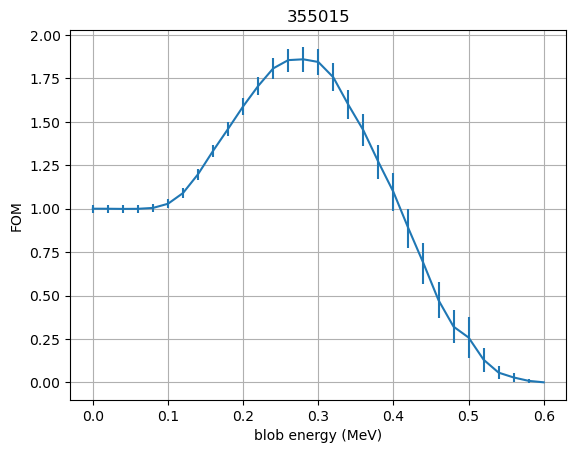

Max FOM as 1.86 at 0.28 MeV
Signal events at peak: 5783.95
Background events at peak: 248.43
Initial signal events: 7787.45
Initial background events: 1558.79
355018






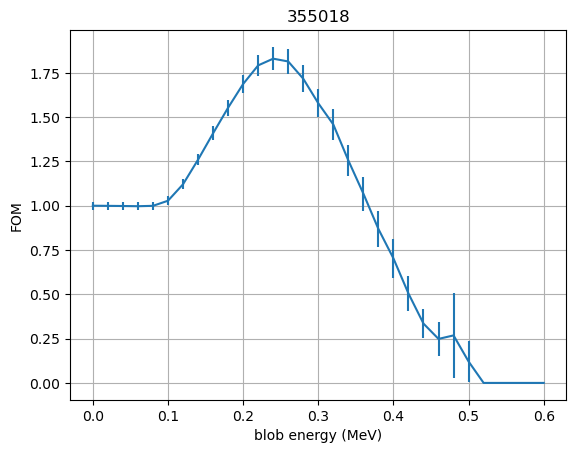

Max FOM as 1.83 at 0.24 MeV
Signal events at peak: 6233.80
Background events at peak: 285.42
Initial signal events: 8143.98
Initial background events: 1630.99
355021






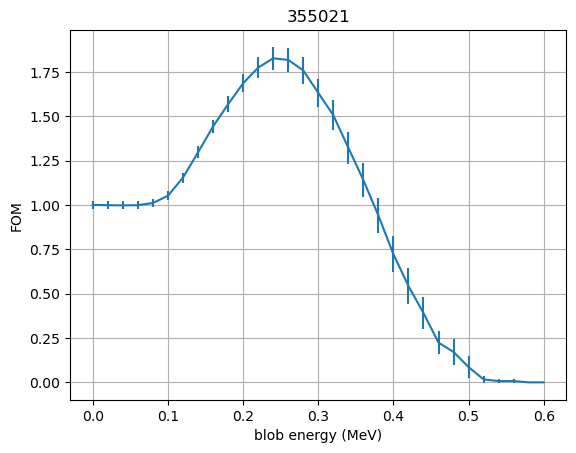

Max FOM as 1.83 at 0.24 MeV
Signal events at peak: 6468.89
Background events at peak: 306.66
Initial signal events: 8386.45
Initial background events: 1719.49
355024






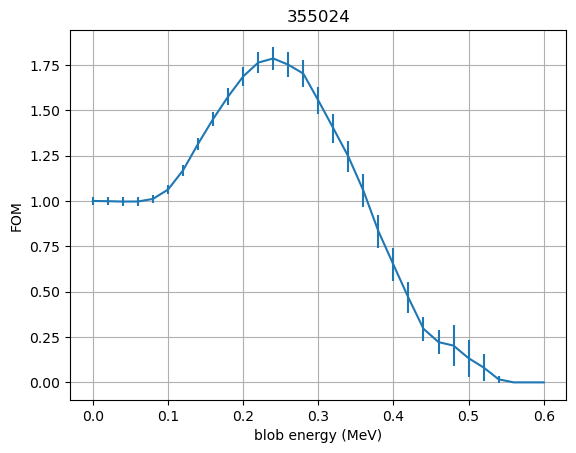

Max FOM as 1.79 at 0.24 MeV
Signal events at peak: 6255.32
Background events at peak: 294.62
Initial signal events: 8510.25
Initial background events: 1738.37
456015






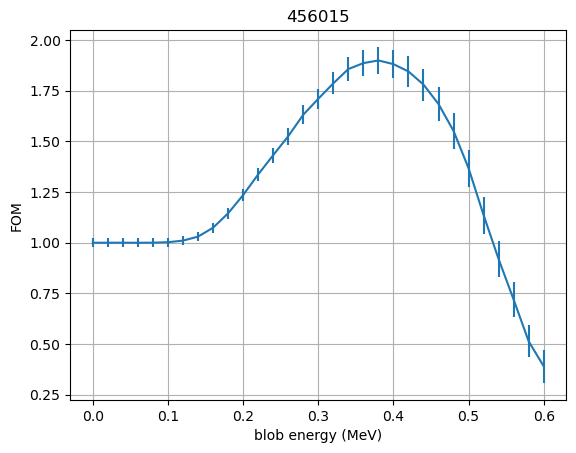

Max FOM as 1.90 at 0.38 MeV
Signal events at peak: 6315.30
Background events at peak: 302.20
Initial signal events: 8357.04
Initial background events: 1908.29
456018






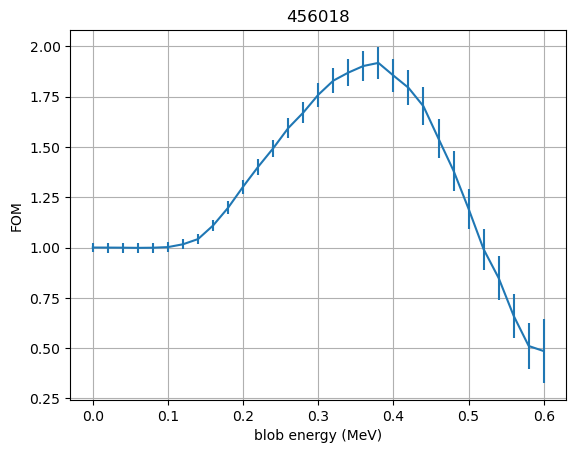

Max FOM as 1.92 at 0.38 MeV
Signal events at peak: 4883.29
Background events at peak: 206.82
Initial signal events: 7048.66
Initial background events: 1584.03
456021






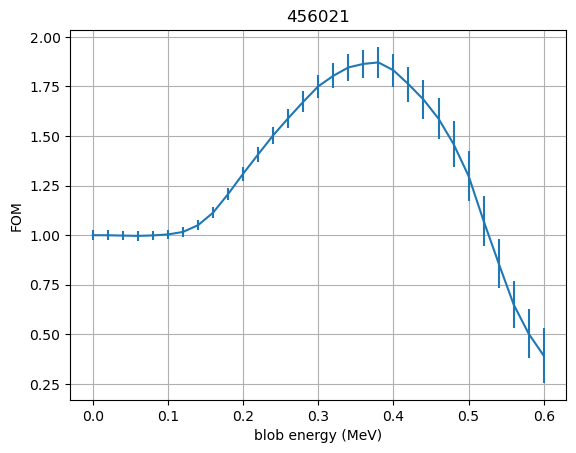

Max FOM as 1.87 at 0.38 MeV
Signal events at peak: 4746.83
Background events at peak: 201.75
Initial signal events: 7168.21
Initial background events: 1610.46
456024






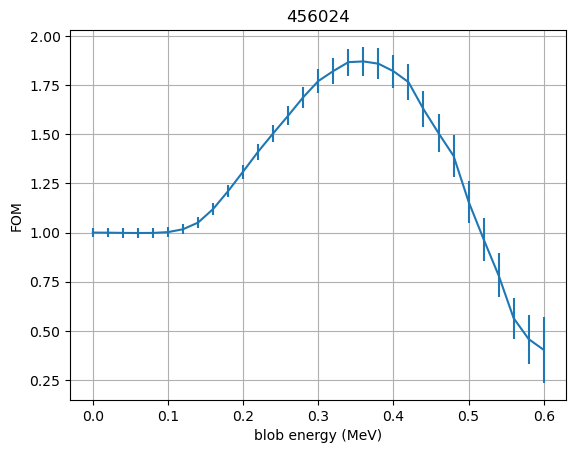

Max FOM as 1.87 at 0.36 MeV
Signal events at peak: 4976.49
Background events at peak: 237.70
Initial signal events: 6888.29
Initial background events: 1593.96
557015






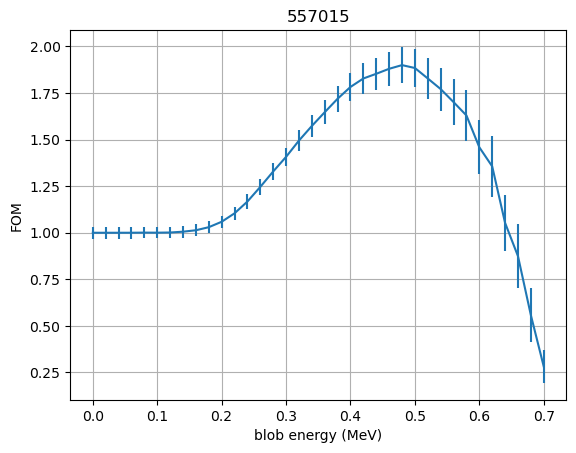

Max FOM as 1.90 at 0.48 MeV
Signal events at peak: 2609.88
Background events at peak: 140.77
Initial signal events: 3867.35
Initial background events: 1115.59
557018






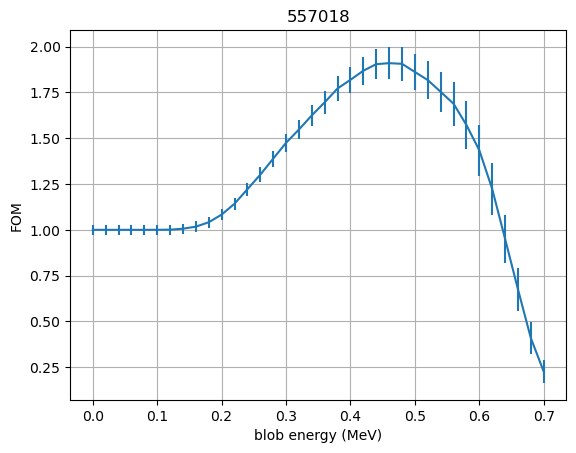

Max FOM as 1.91 at 0.46 MeV
Signal events at peak: 3415.90
Background events at peak: 181.43
Initial signal events: 4883.66
Initial background events: 1351.71
557021






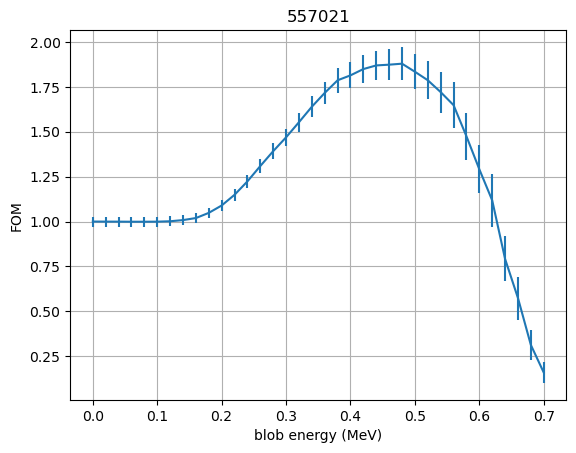

Max FOM as 1.88 at 0.48 MeV
Signal events at peak: 2922.76
Background events at peak: 144.11
Initial signal events: 4806.62
Initial background events: 1376.39
557024






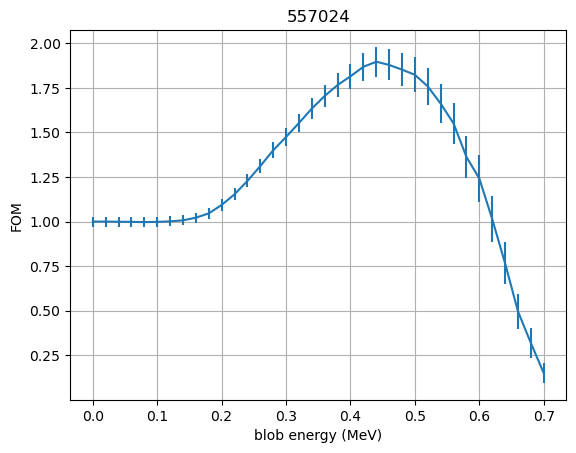

Max FOM as 1.90 at 0.44 MeV
Signal events at peak: 3568.90
Background events at peak: 199.38
Initial signal events: 4933.62
Initial background events: 1370.12
658015






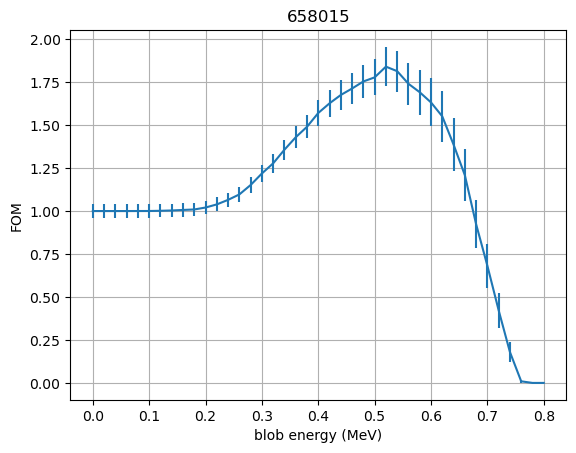

Max FOM as 1.84 at 0.52 MeV
Signal events at peak: 1380.29
Background events at peak: 103.71
Initial signal events: 2161.45
Initial background events: 861.13
658018






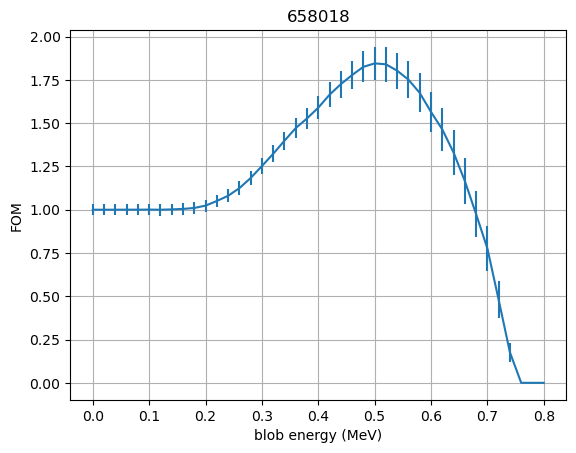

Max FOM as 1.85 at 0.50 MeV
Signal events at peak: 2127.70
Background events at peak: 153.55
Initial signal events: 3066.24
Initial background events: 1085.72
658021






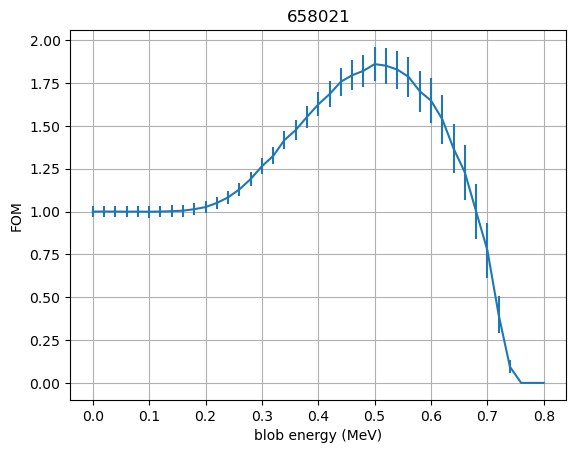

Max FOM as 1.86 at 0.50 MeV
Signal events at peak: 1930.06
Background events at peak: 138.58
Initial signal events: 2883.48
Initial background events: 1070.68
658024






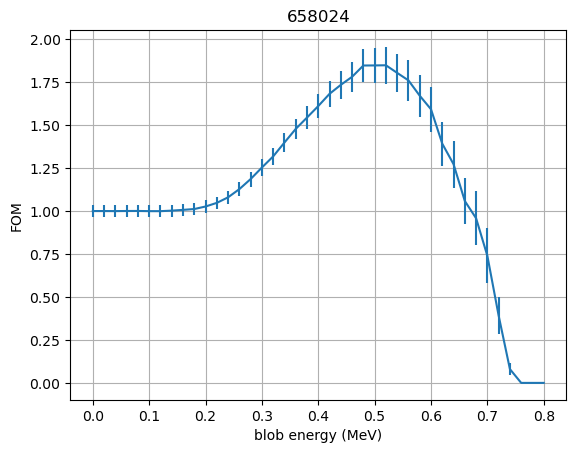

Max FOM as 1.85 at 0.52 MeV
Signal events at peak: 1687.81
Background events at peak: 116.98
Initial signal events: 2717.98
Initial background events: 1036.21


In [6]:

ts_list = [355015, 355018, 355021, 355024, 456015, 456018, 456021, 456024, 557015, 557018, 557021, 557024, 658015, 658018, 658021, 658024]
for timestamp in ts_list:

    FOM_info = read_FOM_csv(f'output/{timestamp}/FOM.csv')


    FOM_clean = FOM_info['fom']
    FOM_clean[(FOM_clean > 5) | (FOM_clean < 0)] = 0
    FOM_err = FOM_info['fom_err']
    FOM_err[(FOM_err > 5) | (FOM_err < 0)] = 0
    print('='*20)
    print(f'{timestamp}')
    print('='*20)
    print('\n\n\n')
    plt.errorbar(FOM_info['cut_list'], FOM_clean, yerr = FOM_err)
    plt.xlabel('blob energy (MeV)')
    plt.title(f'{timestamp}')
    plt.ylabel('FOM')
    plt.grid()
    plt.show()
    max_fom_index = np.argmax(FOM_clean)
    max_fom       = FOM_clean[max_fom_index]
    cut_pos       = FOM_info['cut_list'][max_fom_index]
    print(f"Max FOM as {max_fom:.2f} at {cut_pos:.2f} MeV")
    print(f"Signal events at peak: {FOM_info['ns_l'][max_fom_index]:.2f}")
    print(f"Background events at peak: {FOM_info['nb_l'][max_fom_index]:.2f}")
    print(f"Initial signal events: {FOM_info['ns_l'][0]:.2f}")
    print(f"Initial background events: {FOM_info['nb_l'][0]:.2f}")